In [1]:
import os
import random
from typing import List, Tuple
import glob

import torch
import torchaudio
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import os
from typing import List, Dict, Union, Literal
import torch
from torch.utils.data import Dataset

In [2]:
def extract_speaker_id(path: str) -> str:
    base = os.path.basename(path)
    return base.split("_nohash_")[0]

def split_by_speakers(
    all_files: List[str], split_pct: float = 0.2, seed: int = 42
) -> Tuple[List[str], List[str]]:
    """
    Split filepaths into two disjoint sets by speaker ID.

    Args:
        all_files: list of wav file paths
        split_pct: fraction of speakers to put in the second set
        seed: random seed for reproducibility

    Returns:
        set_a_files, set_b_files
        (e.g., train_files, test_files OR train_files, val_files)
    """
    # Collect all speakers
    speakers = sorted({extract_speaker_id(f) for f in all_files})

    # Shuffle and split speakers
    rng = random.Random(seed)
    rng.shuffle(speakers)

    n_split = int(len(speakers) * split_pct)
    split_speakers = set(speakers[:n_split])

    set_b = [f for f in all_files if extract_speaker_id(f) in split_speakers]
    set_a = [f for f in all_files if extract_speaker_id(f) not in split_speakers]

    return set_a, set_b

In [3]:
# import warnings
# warnings.filterwarnings(
#     "ignore",
#     message=".*torchaudio.load_with_torchcodec.*",
#     category=UserWarning
# )

class SpeechCommandsDataset(Dataset):
    def __init__(
        self,
        file_list: List[str],
        *,
        n_fft: int = 512,
        hop_length: int = 256,
        win_length: int = 512,
        window: Literal["hann", "hamming", "rectangle"] = "hann",
        audio_sequence_length: int = 16000,
        adjust_audio_sequence_length: bool = True,
    ) -> None:
        """
        Dataset for the Speech Commands dataset.

        Args:
            file_list (List[str]): List of paths to .wav audio files.
            n_fft (int, optional): Size of the FFT. Default is 512.
            hop_length (int, optional): Number of audio samples between adjacent STFT frames. Default is 256.
            win_length (int, optional): Size of the window used for each STFT frame. Default is 512.
            window ({"hann", "hamming", "rectangle"}, optional): 
                Type of window function applied before FFT:
                  - "hann": Hann window (cosine-shaped, commonly used to reduce spectral leakage).
                  - "hamming": Hamming window (similar to Hann, slightly less side lobe attenuation).
                  - "rectangle": No windowing (equivalent to all-ones, i.e., a rectangular window).
                Default is "hann".
            audio_sequence_length (int, optional): Target length (in samples) to which each waveform is padded or trimmed. Default is 16000.
            adjust_audio_sequence_length (bool, optional): If True, adjusts adds padding or trimming to make audio_sequence_length equal to the given audio_sequence_length.
        """

        # Build label mapping from folder names
        self.files = file_list
        labels = [os.path.basename(os.path.dirname(f)) for f in self.files]
        self.label2id = {l: i for i, l in enumerate(sorted(set(labels)))}
        self.labels = [self.label2id[l] for l in labels]

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.audio_sequence_length = audio_sequence_length
        self.adjust_audio_sequence_length = adjust_audio_sequence_length

        # Create and register window as a buffer
        if window == "hann":
            self.window = torch.hann_window(self.win_length)
        elif window == "hamming":
            self.window = torch.hamming_window(self.win_length)
        elif window == 'rectangle':
            self.window = torch.ones(self.win_length)
        else:
            raise ValueError(f"Invalid window type: {window}. Choose 'hann' or 'hamming'.")

    def compute_stft(self, waveform: torch.Tensor) -> torch.Tensor:
        return torch.stft(
            waveform, n_fft=self.n_fft, hop_length=self.hop_length,
            win_length=self.win_length, window=self.window, return_complex=True
        ).squeeze(0)  # [freq, time]

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx) -> Dict[str, Union[torch.Tensor, int, str]]:
        path = self.files[idx]

        # torch audio normalize to [-1, 1] using the min max range of the 16-bit PCM [-32768, 32767]
        # a = -32768, b = 32767
        # ( (x - x_min ) / (x_max - x_min) ) * (b-a) + b
        waveform, sr = torchaudio.load(path,normalize=True)
        # zero pad or trim to fixed length
        if waveform.size(1) < self.audio_sequence_length and self.adjust_audio_sequence_length:
            #TODO move to a logger
            #print("Padding waveform from", waveform.size(1), "to", self.audio_sequence_length)
            padding = self.audio_sequence_length - waveform.size(1)
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        elif waveform.size(1) > self.audio_sequence_length:
            #TODO move to a logger
            #print("Trimming waveform from", waveform.size(1), "to", self.audio_sequence_length)
            waveform = waveform[:, :self.audio_sequence_length]

        stft = self.compute_stft(waveform)

        return {
            "raw": waveform,
            "mag": stft.abs(),
            "decibel": 20 * torch.log10(stft.abs() + 1e-9),
            "phase": stft.angle(),
            "real": stft.real,
            "imag": stft.imag,
            "label": self.labels[idx],
            "path": path,
        }

In [4]:
selected_words = [
        "bed", "bird", "cat", "dog", "down", "eight", "five", "four", "go",
        "happy", "house", "left", "marvin", "nine", "no", "off", "on", "one",
        "right", "seven", "sheila", "six", "stop", "three", "tree", "two",
        "up", "wow", "yes", "zero"
    ]
    # Get all wav files
all_files = glob.glob("data/speech_commands_v0.01/*/*.wav")

# Extract all folder names (words) present in the dataset
all_words = sorted({os.path.basename(os.path.dirname(f)) for f in all_files})

# Keep only the files belonging to selected words
filtered_files = [f for f in all_files if os.path.basename(os.path.dirname(f)) in selected_words]

full_dataset = SpeechCommandsDataset(filtered_files)
print("Number of files in the full dataset:", len(full_dataset))
print("Number of classes:", len(full_dataset.label2id))

Number of files in the full dataset: 0
Number of classes: 0


In [5]:
info = torchaudio.info("data/speech_commands_v0.01/yes/0a7c2a8d_nohash_0.wav")
print(info)

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_16306/1346976511.py:1: UserWarning: torchaudio._backend.utils.info has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  info = torchaudio.info("data/speech_commands_v0.01/yes/0a7c2a8d_nohash_0.wav")


LibsndfileError: Error opening 'data/speech_commands_v0.01/yes/0a7c2a8d_nohash_0.wav': System error.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import random, os

# Pick a sample based on a given idx
idx = 420
#idx = 421
sample = full_dataset[idx]
label = os.path.basename(os.path.dirname(sample["path"]))
print("Sampled file path:", sample["path"])

waveform = sample["raw"].squeeze().numpy()
mag = sample["mag"].numpy()
decibel = sample["decibel"].numpy()
phase = sample["phase"].numpy()
real = sample["real"].numpy()
imag = sample["imag"].numpy()

# Plot everything
fig, axes = plt.subplots(6, 1, figsize=(12, 16))

# Raw waveform
axes[0].plot(waveform)
axes[0].set_title(f"Waveform (Word: {label})")
axes[0].set_xlabel("Time (samples)")
axes[0].set_ylabel("Amplitude")
axes[0].grid()

# Magnitude spectrogram (linear scale)
im0 = axes[1].imshow(mag, aspect="auto", origin="lower")
axes[1].set_title("STFT Magnitude (Linear)")
axes[1].set_xlabel("Time frames")
axes[1].set_ylabel("Frequency bins")
fig.colorbar(im0, ax=axes[1])

# Magnitude spectrogram (dB scale)
im1 = axes[2].imshow(decibel, aspect="auto", origin="lower")
axes[2].set_title("STFT Magnitude (dB)")
axes[2].set_xlabel("Time frames")
axes[2].set_ylabel("Frequency bins")
fig.colorbar(im1, ax=axes[2])

# Phase spectrogram
im2 = axes[3].imshow(phase, aspect="auto", origin="lower", cmap="twilight")
axes[3].set_title("STFT Phase (radians)")
axes[3].set_xlabel("Time frames")
axes[3].set_ylabel("Frequency bins")
fig.colorbar(im2, ax=axes[3])

# Real part
im3 = axes[4].imshow(real, aspect="auto", origin="lower", cmap="coolwarm")
axes[4].set_title("STFT Real Part")
axes[4].set_xlabel("Time frames")
axes[4].set_ylabel("Frequency bins")
fig.colorbar(im3, ax=axes[4])

# Imaginary part
im4 = axes[5].imshow(imag, aspect="auto", origin="lower", cmap="coolwarm")
axes[5].set_title("STFT Imaginary Part")
axes[5].set_xlabel("Time frames")
axes[5].set_ylabel("Frequency bins")
fig.colorbar(im4, ax=axes[5])

plt.tight_layout()
plt.show()


IndexError: list index out of range

Untrimmed dataset - Min: 5945, Max: 16000, Mean: 15753.32, Std: 951.74, N: 64721


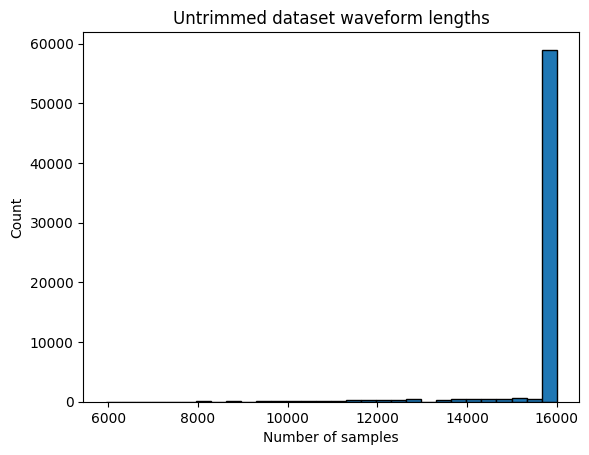

Full dataset - Min: 16000, Max: 16000, Mean: 16000.00, Std: 0.00, N: 64721


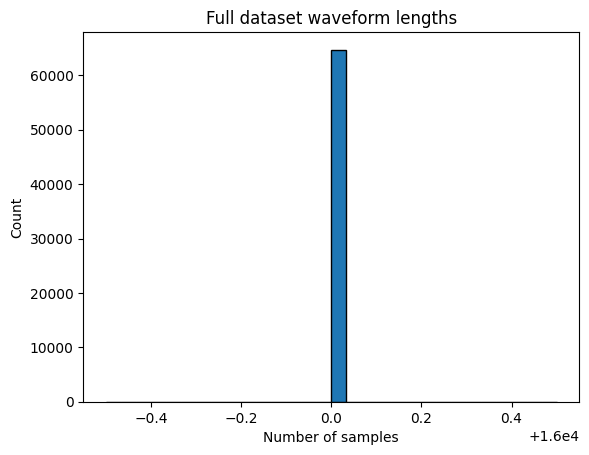

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_lengths(ds, name="Dataset", bins=30, show_hist=True):
    lengths = np.array([ex["raw"].shape[1] for ex in ds])

    print(
        f"{name} - Min: {lengths.min()}, "
        f"Max: {lengths.max()}, "
        f"Mean: {lengths.mean():.2f}, "
        f"Std: {lengths.std():.2f}, "
        f"N: {len(lengths)}"
    )

    if show_hist:
        plt.hist(lengths, bins=bins, edgecolor="black")
        plt.title(f"{name} waveform lengths")
        plt.xlabel("Number of samples")
        plt.ylabel("Count")
        plt.show()

un_trimmed_dataset = SpeechCommandsDataset(
    filtered_files, audio_sequence_length=16000, adjust_audio_sequence_length=False
)

summarize_lengths(un_trimmed_dataset, name="Untrimmed dataset")

summarize_lengths(full_dataset, name="Full dataset")

In [ ]:
train_files, test_files = split_by_speakers(filtered_files, split_pct=0.2, seed=42)
print("Number of training files:", len(train_files))
print("Number of test files:", len(test_files))

Number of training files: 52052
Number of test files: 12669
